## Agentic RAG — Retrieve → Grade → Rewrite → Generate in LangGraph


In [ ]:
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv

load_dotenv()

llm = ChatOpenAI(model="gpt-4o-mini")

DOCS = {
    "langgraph": "LangGraph is a library for building stateful multi-actor LLM applications.",
    "langchain": "LangChain is a framework for LLM-powered applications.",
    "checkpoints": "Checkpoints in LangGraph save and restore agent state across sessions.",
    "tools": "Tools are functions agents use to interact with external systems.",
}


def mock_retrieve(query: str) -> list[str]:
    q = query.lower()
    return [doc for key, doc in DOCS.items() if key in q]

In [ ]:
from typing import TypedDict, Literal


# --- 1. STATE ---
class State(TypedDict):
    question: str
    documents: list[str]
    generation: str
    doc_grade: str
    rewrite_count: int

In [ ]:
from langchain_core.messages import HumanMessage


# --- 2. NODES ---
def retrieve_node(state: State) -> dict:
    docs = mock_retrieve(state["question"])
    print(f"[retrieve] Found {len(docs)} docs for: '{state['question']}'")
    return {"documents": docs}


def grade_node(state: State) -> dict:
    grade = "useful" if state["documents"] else "not_useful"
    print(f"[grade]    → {grade}")
    return {"doc_grade": grade}


def rewrite_node(state: State) -> dict:
    resp = llm.invoke([HumanMessage(f"Rewrite to improve search: '{state['question']}'")])
    count = state.get("rewrite_count", 0) + 1
    print(f"[rewrite #{count}] → '{resp.content[:60]}'")
    return {"question": resp.content, "rewrite_count": count}


def generate_node(state: State) -> dict:
    context = "\n".join(state["documents"]) or "No relevant docs."
    resp = llm.invoke([HumanMessage(f"Answer based on context.\nContext:\n{context}\nQuestion: {state['question']}")])
    print("[generate] Answer ready.")
    return {"generation": resp.content}


def route_grade(state: State) -> Literal["generate", "rewrite_query"]:
    if state["doc_grade"] == "useful" or state.get("rewrite_count", 0) >= 2:
        return "generate"
    return "rewrite_query"

In [13]:
from langgraph.graph import StateGraph, START, END

# --- 3. GRAPH ---
builder = StateGraph(State)

builder.add_node("retrieve", retrieve_node)
builder.add_node("grade", grade_node)
builder.add_node("rewrite_query", rewrite_node)
builder.add_node("generate", generate_node)

builder.add_edge(START, "retrieve")
builder.add_edge("retrieve", "grade")
builder.add_conditional_edges("grade", route_grade, {"generate": "generate", "rewrite_query": "rewrite_query"})
builder.add_edge("rewrite_query", "retrieve")  # loop with new query
builder.add_edge("generate", END)
graph = builder.compile()

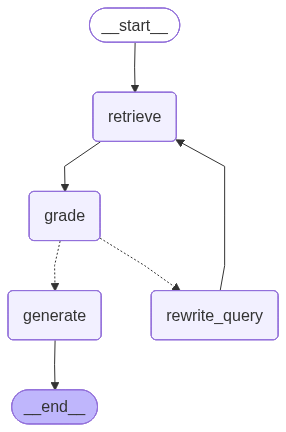

In [14]:
# --- 4. VISUALIZE ---
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [15]:
# --- 5. RUN & TEST ---
question = "What is LangGraph?"
print(f"\n{'='*50}\n❓ {question}")
r = graph.invoke(
    {
        "question": question,
        "documents": [],
        "generation": "",
        "doc_grade": "",
        "rewrite_count": 0,
    }
)
print(f"✅ {r['generation']}")


❓ What is LangGraph?
[retrieve] Found 1 docs for: 'What is LangGraph?'
[grade]    → useful
[generate] Answer ready.
✅ LangGraph is a library designed for creating stateful applications that involve multiple actors and utilize large language models (LLMs).


In [16]:
question = "How do I save agent progress?"
print(f"\n{'='*50}\n❓ {question}")
r = graph.invoke(
    {
        "question": question,
        "documents": [],
        "generation": "",
        "doc_grade": "",
        "rewrite_count": 0,
    }
)
print(f"✅ {r['generation']}")


❓ How do I save agent progress?
[retrieve] Found 0 docs for: 'How do I save agent progress?'
[grade]    → not_useful
[rewrite #1] → '"What are the steps to save my agent's progress?"'
[retrieve] Found 0 docs for: '"What are the steps to save my agent's progress?"'
[grade]    → not_useful
[rewrite #2] → '"What steps can I take to save my agent's progress?"'
[retrieve] Found 0 docs for: '"What steps can I take to save my agent's progress?"'
[grade]    → not_useful
[generate] Answer ready.
✅ To save your agent's progress, you can follow these general steps:

1. **Check for Autosave Features**: Many applications or platforms come with an autosave feature that saves progress automatically. Ensure this feature is enabled.

2. **Manual Save Option**: Look for a "Save" button or option within the application. This is often found in the file menu or on the main interface.

3. **Create Backups**: Regularly create manual backups of your agent’s progress. This could involve exporting data or copy